In [1]:
import sys
!{sys.executable} -m pip install --upgrade pip
! pip install seaborn 

In [2]:
import sys
!{sys.executable} -m pip install seaborn

In [13]:
import sys
!{sys.executable} -m pip install seaborn scikit-learn scipy plotly openpyxl xlrd

  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ------- -------------------------------- 1.6/8.1 MB 9.7 MB/s eta 0:00:01
   -------------------- ------------------- 4.2/8.1 MB 11.1 MB/s eta 0:00:01
   -------------------------------- ------- 6.6/8.1 MB 11.3 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 10.9 MB/s  0:00:00
   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
   -- ------------------------------------- 2.4/37.3 MB 12.2 MB/s eta 0:00:03
   ----- ---------------------------------- 4.7/37.3 MB 11.7 MB/s eta 0:00:03
   ------- -------------------------------- 7.3/37.3 MB 11.6 MB/s eta 0:00:03
   ---------- ----------------------------- 9.7/37.3 MB 11.6 MB/s eta 0:00:03
   ------------- -------------------------- 12.3/37.3 MB 11.7 MB/s eta 0:00:03
   --------------- ------------------------ 14.7/37.3 MB 11.7 MB/s eta 0:00:02
   ---------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [1]:
# All libraries we need for this project
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Make all charts look clean and professional
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.family'] = 'sans-serif'
sns.set_style("whitegrid")

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
# Load both files
bank = pd.read_excel(r"D:\Analytics\Data\Internal_Bank_Dataset.xlsx\Internal_Bank_Dataset.xlsx", sheet_name="case_study1")
cibil = pd.read_excel(r"D:\Analytics\Data\External_Cibil_Dataset.xlsx\External_Cibil_Dataset.xlsx", sheet_name="case_study2")

print("Internal Bank Dataset:", bank.shape)
print("External CIBIL Dataset:", cibil.shape)

Internal Bank Dataset: (51336, 26)
External CIBIL Dataset: (51336, 62)


In [4]:
# Check first 5 rows of each
print("=== BANK DATA ===")
print(bank.head())

print("\n=== CIBIL DATA ===")
print(cibil[['PROSPECTID','AGE','GENDER','EDUCATION',
             'NETMONTHLYINCOME','Credit_Score','Approved_Flag']].head())

=== BANK DATA ===
   PROSPECTID  Total_TL  Tot_Closed_TL  Tot_Active_TL  Total_TL_opened_L6M  \
0           1         5              4              1                    0   
1           2         1              0              1                    0   
2           3         8              0              8                    1   
3           4         1              0              1                    1   
4           5         3              2              1                    0   

   Tot_TL_closed_L6M  pct_tl_open_L6M  pct_tl_closed_L6M  pct_active_tl  \
0                  0            0.000                0.0          0.200   
1                  0            0.000                0.0          1.000   
2                  0            0.125                0.0          1.000   
3                  0            1.000                0.0          1.000   
4                  0            0.000                0.0          0.333   

   pct_closed_tl  ...  CC_TL  Consumer_TL  Gold_TL  Home_TL  P

In [5]:
# Check for actual nulls
print("=== NULL VALUES ===")
print("Bank nulls:", bank.isnull().sum().sum())
print("CIBIL nulls:", cibil.isnull().sum().sum())

=== NULL VALUES ===
Bank nulls: 0
CIBIL nulls: 0


In [6]:
# Check for -99999 sentinel values (means data not available)
print("\n=== -99999 SENTINEL VALUES IN CIBIL ===")
sentinel_cols = (cibil == -99999).sum()
sentinel_cols = sentinel_cols[sentinel_cols > 0]
sentinel_pct = (sentinel_cols / len(cibil) * 100).round(1)


=== -99999 SENTINEL VALUES IN CIBIL ===


In [7]:
sentinel_report = pd.DataFrame({
    'Count': sentinel_cols,
    'Percentage': sentinel_pct
})
print(sentinel_report.sort_values('Percentage', ascending=False))

                              Count  Percentage
CC_utilization                47636        92.8
PL_utilization                44435        86.6
time_since_recent_deliquency  35949        70.0
max_delinquency_level         35949        70.0
time_since_first_deliquency   35949        70.0
max_unsec_exposure_inPct      23178        45.1
max_deliq_6mts                12890        25.1
max_deliq_12mts               10832        21.1
PL_enq_L12m                    6321        12.3
CC_enq_L12m                    6321        12.3
tot_enq                        6321        12.3
CC_enq                         6321        12.3
CC_enq_L6m                     6321        12.3
enq_L3m                        6321        12.3
PL_enq_L6m                     6321        12.3
PL_enq                         6321        12.3
time_since_recent_enq          6321        12.3
enq_L12m                       6321        12.3
enq_L6m                        6321        12.3
time_since_recent_payment      4291     

In [8]:
# CC_utilization (92.8% missing) and PL_utilization (86.6% missing)
# are too incomplete to use — we drop them
cols_to_drop = ['CC_utilization', 'PL_utilization']
cibil_clean = cibil.drop(columns=cols_to_drop)

print("Columns dropped:", cols_to_drop)
print("CIBIL shape after drop:", cibil_clean.shape)

# Document reason (important for interview)
print("\nReason: CC_utilization had 92.8% missing values (-99999).")
print("Using such columns would introduce severe bias in analysis.")

Columns dropped: ['CC_utilization', 'PL_utilization']
CIBIL shape after drop: (51336, 60)

Reason: CC_utilization had 92.8% missing values (-99999).
Using such columns would introduce severe bias in analysis.


Cell 6 — Replace -99999 With NaN Then Fill With Median

In [9]:
# Step 1: Replace all -99999 with NaN
cibil_clean = cibil_clean.replace(-99999, np.nan)

# Step 2: Fill numeric NaN columns with median
numeric_cols = cibil_clean.select_dtypes(include=[np.number]).columns
cibil_clean[numeric_cols] = cibil_clean[numeric_cols].fillna(
    cibil_clean[numeric_cols].median()
)


In [10]:
# Step 3: Same for bank dataset
bank_clean = bank.replace(-99999, np.nan)
numeric_bank = bank_clean.select_dtypes(include=[np.number]).columns
bank_clean[numeric_bank] = bank_clean[numeric_bank].fillna(
    bank_clean[numeric_bank].median()
)

In [11]:
# Verify no more -99999
print("Remaining -99999 in CIBIL:", (cibil_clean == -99999).sum().sum())
print("Remaining -99999 in Bank:", (bank_clean == -99999).sum().sum())
print("\nWhy median? Median is robust to outliers unlike mean.")

Remaining -99999 in CIBIL: 0
Remaining -99999 in Bank: 0

Why median? Median is robust to outliers unlike mean.


Handle Income Outliers Using IQR

In [12]:
#NETMONTHLYINCOME has extreme outliers (max ₹25 lakhs, mean ₹26k)
#We cap using IQR method — standard practice in banking analytics

Q1 = cibil_clean['NETMONTHLYINCOME'].quantile(0.25)
Q3 = cibil_clean['NETMONTHLYINCOME'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR


print(f"Q1: ₹{Q1:,.0f}")
print(f"Q3: ₹{Q3:,.0f}")
print(f"IQR: ₹{IQR:,.0f}")
print(f"Lower bound: ₹{lower:,.0f}")
print(f"Upper bound: ₹{upper:,.0f}")

Q1: ₹18,000
Q3: ₹30,000
IQR: ₹12,000
Lower bound: ₹0
Upper bound: ₹48,000


In [13]:
# Count outliers before capping
outliers_before = ((cibil_clean['NETMONTHLYINCOME'] < lower) |
                   (cibil_clean['NETMONTHLYINCOME'] > upper)).sum()
print(f"\nOutliers found: {outliers_before}")


Outliers found: 3106


In [14]:
# Cap the outliers
cibil_clean['NETMONTHLYINCOME'] = cibil_clean['NETMONTHLYINCOME'].clip(lower, upper)

print(f"Income after capping — Max: ₹{cibil_clean['NETMONTHLYINCOME'].max():,.0f}")
print("\nWhy IQR? It removes extreme values without deleting rows.")

Income after capping — Max: ₹48,000

Why IQR? It removes extreme values without deleting rows.


Merge Both Datasets

#Join on PROSPECTID — same as SQL JOIN we did earlier



In [15]:
master = pd.merge(bank_clean, cibil_clean, on='PROSPECTID', how='inner')

print("Master dataset shape:", master.shape)
print("Columns:", master.shape[1])
print("\nApproved_Flag distribution:")
print(master['Approved_Flag'].value_counts())

Master dataset shape: (51336, 85)
Columns: 85

Approved_Flag distribution:
Approved_Flag
P2    32199
P3     7452
P4     5882
P1     5803
Name: count, dtype: int64


 Chart 1: Risk Tier Distribution (Donut Chart)

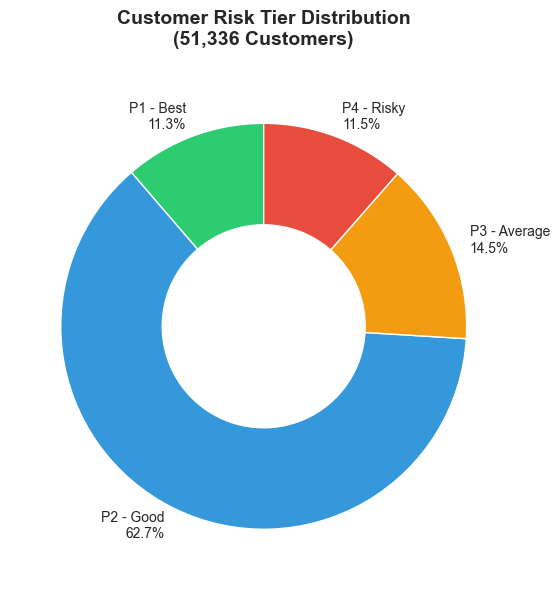


Insight: 62.7% customers are good borrowers (P2).
11.5% are high-risk (P4) — 5,882 customers needing close monitoring.


In [16]:
fig, ax = plt.subplots(figsize=(8, 6))

flag_counts = master['Approved_Flag'].value_counts().sort_index()
colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c']
labels = ['P1 - Best\n11.3%', 'P2 - Good\n62.7%',
          'P3 - Average\n14.5%', 'P4 - Risky\n11.5%']

wedges, texts = ax.pie(
    flag_counts,
    labels=labels,
    colors=colors,
    startangle=90,
    wedgeprops=dict(width=0.5)
)

ax.set_title('Customer Risk Tier Distribution\n(51,336 Customers)',
             fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('chart1_risk_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nInsight: 62.7% customers are good borrowers (P2).")
print("11.5% are high-risk (P4) — 5,882 customers needing close monitoring.")

 Chart 2: Credit Score by Risk Tier (Box Plot)

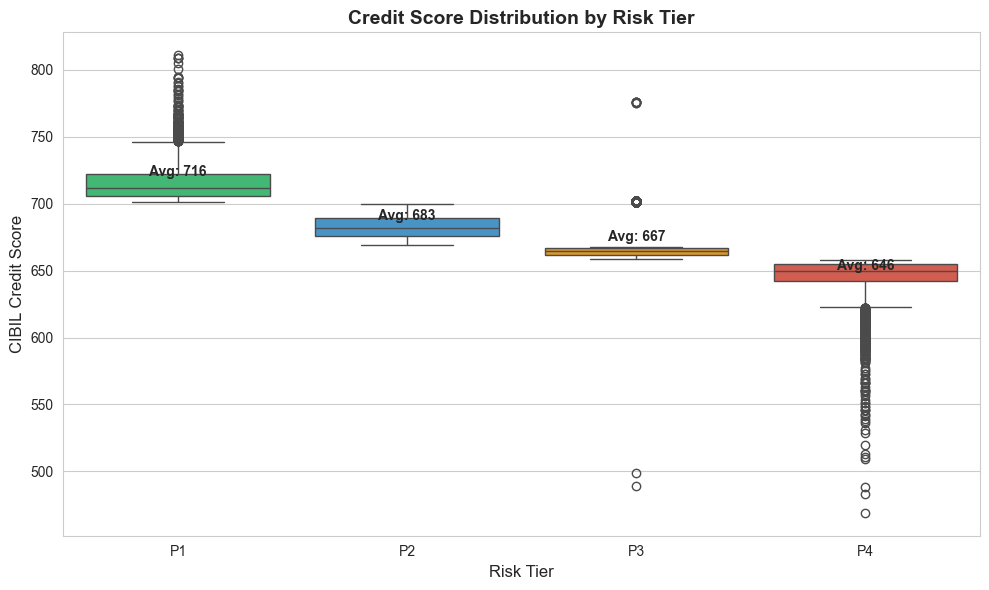


Insight: Clear 70-point gap between P1 (716) and P4 (645).
Score 700+ is the visible threshold for P1 approval.


In [17]:
fig, ax = plt.subplots(figsize=(10, 6))

order = ['P1', 'P2', 'P3', 'P4']
colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c']

sns.boxplot(data=master, x='Approved_Flag', y='Credit_Score',
            order=order, palette=colors, ax=ax)

ax.set_title('Credit Score Distribution by Risk Tier',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Risk Tier', fontsize=12)
ax.set_ylabel('CIBIL Credit Score', fontsize=12)

# Add mean score labels on each box
for i, tier in enumerate(order):
    mean_val = master[master['Approved_Flag'] == tier]['Credit_Score'].mean()
    ax.text(i, mean_val + 5, f'Avg: {mean_val:.0f}',
            ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('chart2_credit_score_tiers.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nInsight: Clear 70-point gap between P1 (716) and P4 (645).")
print("Score 700+ is the visible threshold for P1 approval.")

Chart 3: Credit Hunger Analysis (Bar Chart)

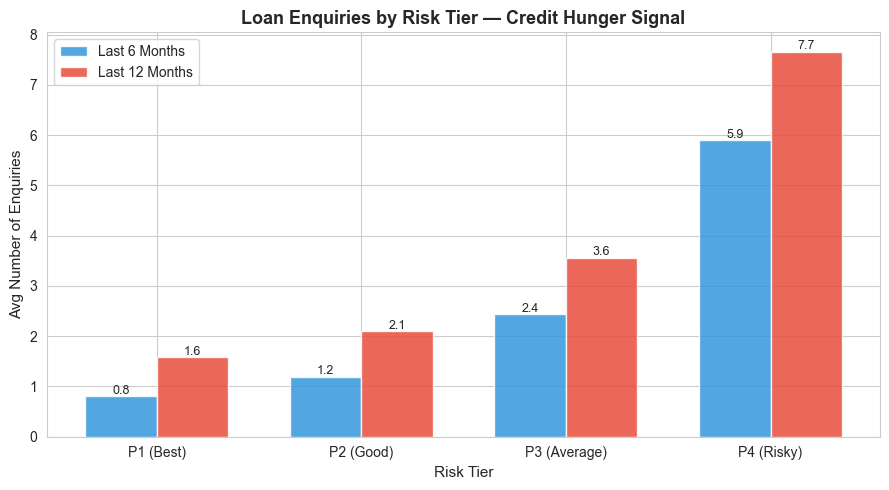


Insight: P4 customers made 6x more enquiries than P1 in 6 months.
Credit hunger is the strongest early warning signal of financial stress.


In [18]:
fig, ax = plt.subplots(figsize=(9, 5))

enq_data = master.groupby('Approved_Flag')[['enq_L6m', 'enq_L12m']].mean()
enq_data = enq_data.loc[['P1', 'P2', 'P3', 'P4']]

x = np.arange(len(enq_data))
width = 0.35

bars1 = ax.bar(x - width/2, enq_data['enq_L6m'],
               width, label='Last 6 Months', color='#3498db', alpha=0.85)
bars2 = ax.bar(x + width/2, enq_data['enq_L12m'],
               width, label='Last 12 Months', color='#e74c3c', alpha=0.85)

ax.set_title('Loan Enquiries by Risk Tier — Credit Hunger Signal',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Risk Tier', fontsize=11)
ax.set_ylabel('Avg Number of Enquiries', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(['P1 (Best)', 'P2 (Good)', 'P3 (Average)', 'P4 (Risky)'])
ax.legend()

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{bar.get_height():.1f}', ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{bar.get_height():.1f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('chart3_credit_hunger.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nInsight: P4 customers made 6x more enquiries than P1 in 6 months.")
print("Credit hunger is the strongest early warning signal of financial stress.")

Chart 4: Missed Payments by Loan Type (Horizontal Bar)

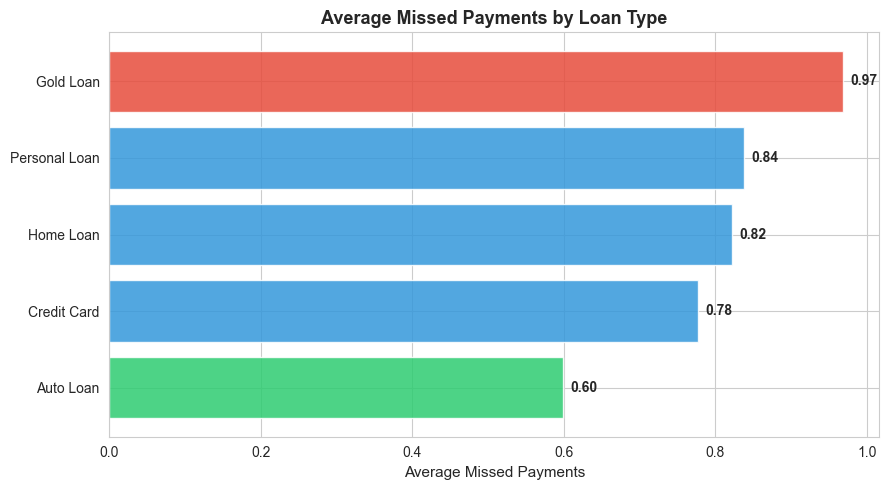


Insight: Gold loans have highest missed payments despite being secured.
Auto loans are the most reliably repaid product.


In [19]:
fig, ax = plt.subplots(figsize=(9, 5))

loan_missed = {
    'Gold Loan':      master[master['Gold_TL'] > 0]['Tot_Missed_Pmnt'].mean(),
    'Personal Loan':  master[master['PL_TL'] > 0]['Tot_Missed_Pmnt'].mean(),
    'Home Loan':      master[master['Home_TL'] > 0]['Tot_Missed_Pmnt'].mean(),
    'Credit Card':    master[master['CC_TL'] > 0]['Tot_Missed_Pmnt'].mean(),
    'Auto Loan':      master[master['Auto_TL'] > 0]['Tot_Missed_Pmnt'].mean(),
}

loan_df = pd.Series(loan_missed).sort_values(ascending=True)
colors = ['#2ecc71' if v == loan_df.min()
          else '#e74c3c' if v == loan_df.max()
          else '#3498db' for v in loan_df]

bars = ax.barh(loan_df.index, loan_df.values, color=colors, alpha=0.85)

ax.set_title('Average Missed Payments by Loan Type',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Average Missed Payments', fontsize=11)

for bar, val in zip(bars, loan_df.values):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('chart4_missed_payments_loantype.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nInsight: Gold loans have highest missed payments despite being secured.")
print("Auto loans are the most reliably repaid product.")

Chart 5: Risk Profile by Education (Stacked Bar)

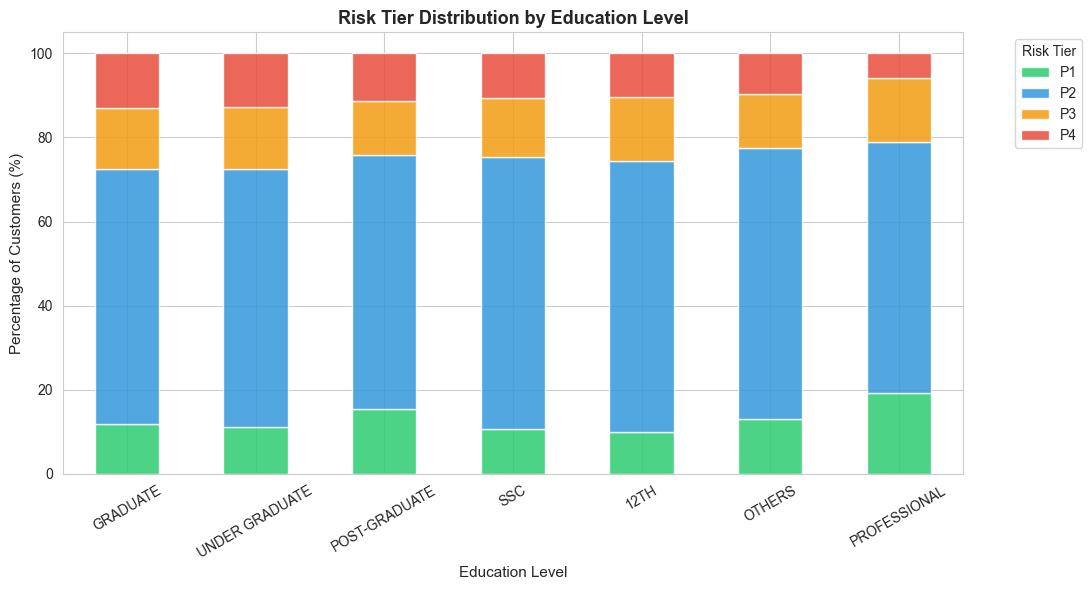


Insight: Professional degree holders have lowest P4 rate (5.9%).
Graduates carry highest risk at 13% — unexpected finding.


In [20]:
fig, ax = plt.subplots(figsize=(11, 6))

edu_risk = master.groupby('EDUCATION')['Approved_Flag'].value_counts(
    normalize=True).unstack() * 100
edu_risk = edu_risk[['P1', 'P2', 'P3', 'P4']]
edu_risk = edu_risk.sort_values('P4', ascending=False)

edu_risk.plot(kind='bar', stacked=True, ax=ax,
              color=['#2ecc71', '#3498db', '#f39c12', '#e74c3c'],
              alpha=0.85)

ax.set_title('Risk Tier Distribution by Education Level',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Education Level', fontsize=11)
ax.set_ylabel('Percentage of Customers (%)', fontsize=11)
ax.legend(title='Risk Tier', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('chart5_education_risk.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nInsight: Professional degree holders have lowest P4 rate (5.9%).")
print("Graduates carry highest risk at 13% — unexpected finding.")

 Export Clean Data for Power BI

In [21]:
# Save the final cleaned master dataset
master.to_csv('master_credit_clean.csv', index=False)

print("Clean dataset exported: master_credit_clean.csv")
print("Shape:", master.shape)
print("\nThis file will be imported directly into Power BI.")
print("\nFiles saved:")
print("  - master_credit_clean.csv  → for Power BI")
print("  - chart1_risk_distribution.png")
print("  - chart2_credit_score_tiers.png")
print("  - chart3_credit_hunger.png")
print("  - chart4_missed_payments_loantype.png")
print("  - chart5_education_risk.png")

Clean dataset exported: master_credit_clean.csv
Shape: (51336, 85)

This file will be imported directly into Power BI.

Files saved:
  - master_credit_clean.csv  → for Power BI
  - chart1_risk_distribution.png
  - chart2_credit_score_tiers.png
  - chart3_credit_hunger.png
  - chart4_missed_payments_loantype.png
  - chart5_education_risk.png


 Summary of EDA Findings

In [22]:
print("=" * 55)
print("   EDA COMPLETE — KEY FINDINGS SUMMARY")
print("=" * 55)

print("""
1. RISK DISTRIBUTION
   62.7% customers are P2 (good), 11.5% are P4 (risky)

2. CREDIT SCORE THRESHOLD
   P1 minimum score is 701 — bank uses 700 as approval line

3. GOLD LOANS ARE RISKIEST
   Highest missed payments (0.97) despite collateral backing

4. INCOME IS NOT A PREDICTOR
   Only ₹1,679 difference between P1 and P4 avg income

5. CREDIT HUNGER = STRONGEST SIGNAL
   P4 customers made 8x more enquiries than P1 in 6 months

6. PROFESSIONALS ARE SAFEST BORROWERS
   Only 5.9% P4 rate vs 13% for graduates

7. UNEXPECTED: P1 HAS LOWEST CLEAN PAYMENT RATE
   55.1% zero missed payments — lower than P2, P3, P4
   Proves multi-factor model beats single-metric decisions
""")

   EDA COMPLETE — KEY FINDINGS SUMMARY

1. RISK DISTRIBUTION
   62.7% customers are P2 (good), 11.5% are P4 (risky)

2. CREDIT SCORE THRESHOLD
   P1 minimum score is 701 — bank uses 700 as approval line

3. GOLD LOANS ARE RISKIEST
   Highest missed payments (0.97) despite collateral backing

4. INCOME IS NOT A PREDICTOR
   Only ₹1,679 difference between P1 and P4 avg income

5. CREDIT HUNGER = STRONGEST SIGNAL
   P4 customers made 8x more enquiries than P1 in 6 months

6. PROFESSIONALS ARE SAFEST BORROWERS
   Only 5.9% P4 rate vs 13% for graduates

7. UNEXPECTED: P1 HAS LOWEST CLEAN PAYMENT RATE
   55.1% zero missed payments — lower than P2, P3, P4
   Proves multi-factor model beats single-metric decisions



In [16]:
# Create loan type summary table for Power BI
loan_summary = pd.DataFrame({
    'Loan_Type': ['Gold Loan', 'Personal Loan', 'Home Loan', 'Credit Card', 'Auto Loan'],
    'Avg_Missed_Payments': [
        master[master['Gold_TL'] > 0]['Tot_Missed_Pmnt'].mean(),
        master[master['PL_TL'] > 0]['Tot_Missed_Pmnt'].mean(),
        master[master['Home_TL'] > 0]['Tot_Missed_Pmnt'].mean(),
        master[master['CC_TL'] > 0]['Tot_Missed_Pmnt'].mean(),
        master[master['Auto_TL'] > 0]['Tot_Missed_Pmnt'].mean()
    ]
}).round(2)

loan_summary = loan_summary.sort_values('Avg_Missed_Payments', ascending=False)
print(loan_summary)

# Save as CSV
loan_summary.to_csv('loan_missed_summary.csv', index=False)
print("\nSaved: loan_missed_summary.csv")

       Loan_Type  Avg_Missed_Payments
0      Gold Loan                 0.97
1  Personal Loan                 0.84
2      Home Loan                 0.82
3    Credit Card                 0.78
4      Auto Loan                 0.60

Saved: loan_missed_summary.csv
